imports part

In [1]:
import pandas as pd
import numpy as np

from google_play_scraper import reviews, Sort

import warnings
warnings.filterwarnings("ignore")

define apps part

In [2]:
apps = {
    "CBE": "com.combanketh.mobilebanking",
    "BOA": "com.boa.boaMobileBanking",
    "Dashen": "com.dashen.dashensuperapp"
}

scrape reviews

In [3]:
all_reviews = []

for bank, app_id in apps.items():

    print(f"Scraping {bank} reviews...")

    result, continuation_token = reviews(
        app_id,
        lang="en",
        country="et",
        sort=Sort.NEWEST,
        count=400
    )

    for review in result:
        all_reviews.append({
            "review": review["content"],
            "rating": review["score"],
            "date": review["at"],
            "bank": bank,
            "source": "Google Play"
        })

print("Scraping complete.")

Scraping CBE reviews...
Scraping BOA reviews...
Scraping Dashen reviews...
Scraping complete.


Create DataFrame

In [4]:
df = pd.DataFrame(all_reviews)

df.head()

,review,rating,date,bank,source
0,nays,5,2026-05-17 18:46:14,CBE,Google Play
1,very very good 👍 thanks commercial bank of eth...,5,2026-05-17 17:03:51,CBE,Google Play
2,so nice,5,2026-05-17 16:12:24,CBE,Google Play
3,fantastic,5,2026-05-17 15:55:05,CBE,Google Play
4,very nice,5,2026-05-17 14:33:09,CBE,Google Play


dataset info , removing missing values and duplicates

In [5]:
df.info()
df.isnull().sum()
df.dropna(subset=["review", "rating"], inplace=True)
df.drop_duplicates(inplace=True)
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   review  1200 non-null   str           
 1   rating  1200 non-null   int64         
 2   date    1200 non-null   datetime64[us]
 3   bank    1200 non-null   str           
 4   source  1200 non-null   str           
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 47.0 KB


(1200, 5)

format date

In [6]:
df["date"] = pd.to_datetime(df["date"])

df["date"] = df["date"].dt.strftime("%Y-%m-%d")

final columns and saving clean datasets

In [7]:
df = df[
    ["review", "rating", "date", "bank", "source"]
]

df.head()
df.to_csv(
    "../data/bank_reviews_clean.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.


basic statstics

In [8]:
df["review_length"] = df["review"].str.len()

df["review_length"].describe()

count    1200.000000
mean       44.675833
std        72.136957
min         1.000000
25%         7.000000
50%        16.000000
75%        49.000000
max       498.000000
Name: review_length, dtype: float64

reviews per bank

In [9]:
df["bank"].value_counts()

bank
CBE       400
BOA       400
Dashen    400
Name: count, dtype: int64

visualization

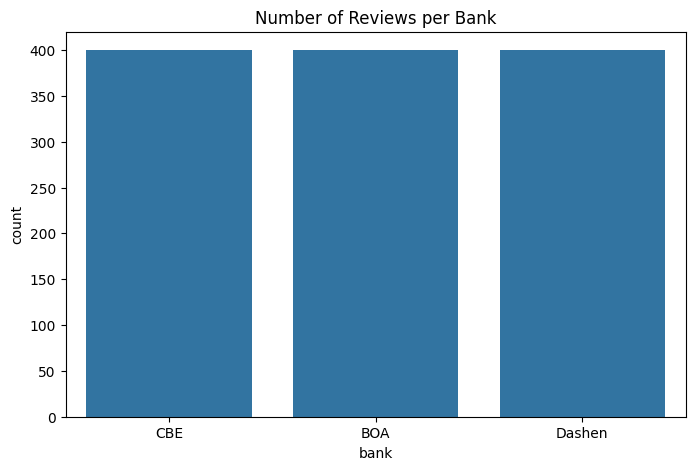

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="bank")

plt.title("Number of Reviews per Bank")

plt.show()

rating distribution

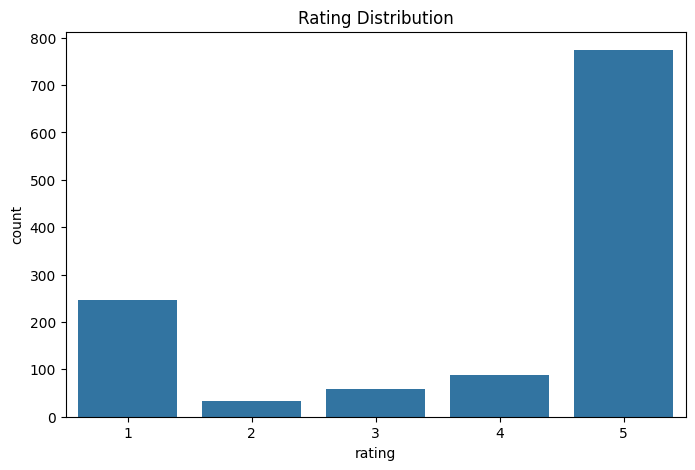

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="rating")

plt.title("Rating Distribution")

plt.show()

review length histogram

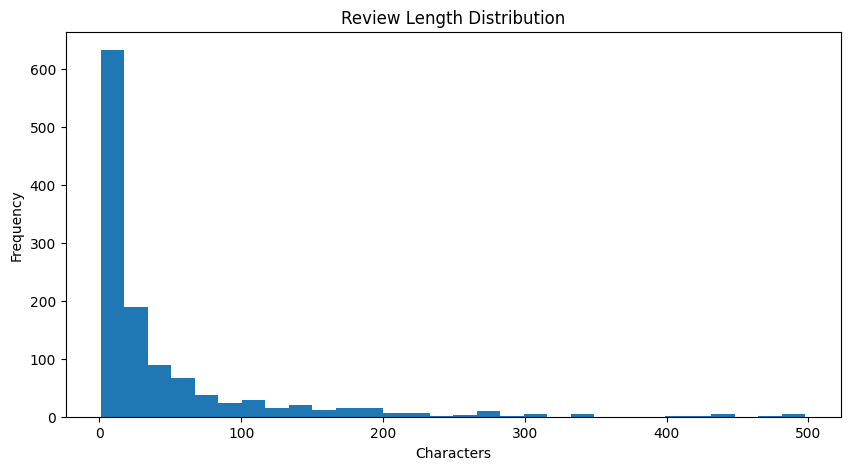

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df["review_length"], bins=30)

plt.title("Review Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()